# 📚 LINEAR REGRESSION: The Complete Learning Guide
## From Basics to Advanced Topics with Real-World Examples

**Author's Note:** This is a comprehensive, interactive guide designed for complete beginners. No scary math—just clear explanations with working code and beautiful visualizations.

---

## 📖 TABLE OF CONTENTS

### **PART 1: FOUNDATIONS** 🏗️
1. [Introduction & Concepts](#introduction)
2. [The Magic Formula: y = β₀ + β₁x](#formula)
3. [Understanding Slope & Intercept](#slope-intercept)

### **PART 2: SIMPLE EXAMPLES** ☕
4. [Coffee Shop: Single Feature](#coffee-single)
5. [Coffee Shop: Multiple Features](#coffee-multiple)
6. [Real Estate Comparison](#real-estate)
7. [Visualizing Different Slopes](#slopes-viz)

### **PART 3: ADVANCED TOPICS** 🚀
8. [Overfitting vs Underfitting](#overfitting)
9. [Regularization Techniques](#regularization)
10. [Evaluation Metrics](#metrics)
11. [Hypothesis Testing](#hypothesis-testing)
12. [Categorical Data & Encoding](#categorical)

### **PART 4: MACHINE LEARNING** 🤖
13. [Gradient Descent Algorithm](#gradient-descent)
14. [How Models Actually Learn](#learning)

### **PART 5: REFERENCES & RESOURCES** 🔗
15. [References & Further Reading](#references)
16. [Quick Reference Guide](#quick-ref)
17. [Mastery Checklist](#checklist)

---

# PART 1: FOUNDATIONS 🏗️

## <a id="introduction"></a>1️⃣ INTRODUCTION: What is Linear Regression?

Linear regression answers a simple question:

**"If I know X, can I predict Y?"**

### Real-World Examples:
- 📊 **Sales:** If I know customers → Can I predict sales?
- 🏠 **Real Estate:** If I know square feet → Can I predict price?
- ☕ **Coffee Shop:** If I know temperature → Can I predict coffee sold?
- 📚 **Student Performance:** If I know study hours → Can I predict test score?
- 🌡️ **Physics:** If I know distance → Can I predict time?

### Key Insight:
Linear regression finds a **straight line** that best fits your data. That line represents the relationship between X and Y.

### What You'll Understand After This Guide:
✅ What slope and intercept mean (and why they matter)
✅ How to fit a line to data
✅ How to make predictions
✅ When your model is too simple or too complex
✅ How to fix problems with regularization
✅ How machines actually "learn" (gradient descent)
✅ How to evaluate if your model is good
✅ How to handle categorical data (text data)
✅ How to perform statistical tests

**Let's begin! 🚀**

## <a id="formula"></a>2️⃣ THE MAGIC FORMULA: y = β₀ + β₁x

### The Simple Version (Algebra Class)
$$ y = mx + b $$

**What each means:**
- **y** = Output (what we want to predict)
- **m** = Slope (how steep the line is)
- **x** = Input (what we know)
- **b** = Intercept (where the line crosses the y-axis)

### The Statistical Version (What Scientists Use)
$$ \hat{y} = \beta_0 + \beta_1 x $$

**The same thing, fancier names:**

| Algebra | Statistics | Meaning | Example |
|---------|------------|---------|----------|
| m | β₁ | Slope | $20 per customer |
| b | β₀ | Intercept | $50 base cost |
| x | x | Input variable | Number of customers |
| y | ŷ (y-hat) | Predicted output | Predicted sales |
| Any β | Coefficient | Any number in equation | Could be β₀ or β₁ |

### Translation Table
✅ **Coefficient = Just a number in the equation**
✅ **β₀ and β₁ are both coefficients**
✅ **y-hat (ŷ) means "predicted y" (not actual y)**

### Remember:
- **β₀ (beta-zero)** - The starting point (when x = 0)
- **β₁ (beta-one)** - How much y changes for each unit of x
- **All of them are coefficients!**

## <a id="slope-intercept"></a>3️⃣ UNDERSTANDING SLOPE & INTERCEPT

### Slope (β₁): The "Steepness"
**Definition:** How much does Y change when X increases by 1?

**Examples:**
- Slope = $20 means: Each 1 more customer = $20 more revenue
- Slope = 0.5 means: Each 1 more hour of study = 0.5 more points
- Slope = -2 means: Each 1 degree warmer = 2 fewer hot coffees sold

### Intercept (β₀): The "Starting Point"
**Definition:** What's the value of Y when X = 0?

**Examples:**
- Intercept = $50 means: Even with 0 customers, we have $50 revenue (subscription?)
- Intercept = 60 means: A student gets 60 points with 0 hours of study (base knowledge)
- Intercept = 100 means: We sell 100 coffees even at 0°F (indoor only?)

### Visual Representation

```
        y
        |
    12  |           /  ← SLOPE (β₁)
    11  |          /     The line's steepness
    10  |         /      Rise/Run = change in y / change in x  
     9  |        /
     8  |       /
     7  |      /
     6  |     /
     5  |    /
     4  |   /
     3  |  /
     2  | /
     1  |/ ← Line equation: y = β₀ + β₁·x
     0  +-------- x
        ↑
        β₀ (INTERCEPT)
        Where line crosses y-axis (x=0)
```

**Quick Formula Reference:**
- **β₁ (Slope)** = (y₂ - y₁) / (x₂ - x₁) — how much y increases per unit of x
- **β₀ (Intercept)** = y-value when x = 0 — the "baseline" or "starting point"

### Key Insight:
🎯 **Together, slope + intercept = Your complete prediction line!**

# PART 2: SIMPLE EXAMPLES ☕

## <a id="coffee-single"></a>4️⃣ COFFEE SHOP: Single Feature Prediction

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from scipy import stats
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# 1. SIMPLE COFFEE SHOP - Single Feature (Customers)
print("="*70)
print("☕ COFFEE SHOP: PREDICTING SALES FROM CUSTOMER COUNT")
print("="*70)
print()

# Create data
customers = np.array([10, 20, 30, 40, 50])
sales = np.array([200, 400, 600, 800, 1000])

# Display data
coffee_df = pd.DataFrame({
    'Customers': customers,
    'Sales ($)': sales
})
print("\n📊 DATA:")
print(coffee_df.to_string(index=False))
print()

# Reshape for sklearn
X_coffee = customers.reshape(-1, 1)
y_coffee = sales

# Fit model
coffee_model = LinearRegression()
coffee_model.fit(X_coffee, y_coffee)

# Get coefficients
coffee_intercept = coffee_model.intercept_  # β₀
coffee_slope = coffee_model.coef_[0]        # β₁

print("\n🎯 FOUND COEFFICIENTS:")
print(f"  β₀ (Intercept) = {coffee_intercept:.2f}")
print(f"  β₁ (Slope) = {coffee_slope:.2f}")
print()
print(f"📝 EQUATION: Sales = {coffee_intercept:.2f} + {coffee_slope:.2f} × Customers")
print()

# Make predictions
y_pred_coffee = coffee_model.predict(X_coffee)

print("\n🔮 PREDICTIONS:")
pred_df = pd.DataFrame({
    'Customers': customers,
    'Actual Sales': sales,
    'Predicted Sales': y_pred_coffee.astype(int),
    'Error': (sales - y_pred_coffee).astype(int)
})
print(pred_df.to_string(index=False))
print()
print(f"✅ R² Score (Accuracy): {coffee_model.score(X_coffee, y_coffee):.4f}")
print("   (1.0 = Perfect fit, 0.0 = No fit)")
print()
print("="*70)

☕ COFFEE SHOP: PREDICTING SALES FROM CUSTOMER COUNT


📊 DATA:
 Customers  Sales ($)
        10        200
        20        400
        30        600
        40        800
        50       1000


🎯 FOUND COEFFICIENTS:
  β₀ (Intercept) = 0.00
  β₁ (Slope) = 20.00

📝 EQUATION: Sales = 0.00 + 20.00 × Customers


🔮 PREDICTIONS:
 Customers  Actual Sales  Predicted Sales  Error
        10           200              200      0
        20           400              400      0
        30           600              600      0
        40           800              800      0
        50          1000              999      0

✅ R² Score (Accuracy): 1.0000
   (1.0 = Perfect fit, 0.0 = No fit)



## <a id="coffee-multiple"></a>5️⃣ COFFEE SHOP: Multiple Features (The Real World!)

In real life, coffee sales depend on MORE than just customers!

**Multiple features that affect coffee sales:**
- 👥 Number of customers
- 🌡️ Temperature (hot days = less hot coffee)
- 📅 Day of week (weekends busier?)
- 💰 Marketing spend
- ⏰ Hours open
- 📍 Location quality

This is called **"Multiple Linear Regression"**

$$ y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n $$


☕ COFFEE SHOP: MULTIPLE FEATURES PREDICTION


📊 COFFEE SHOP DATA (Multiple Features):
 Customers  Temperature (°F)  Marketing Spend ($)  Hours Open  Location Quality (1-10)  Sales ($)
        15                65                  100           8                        7        450
        25                72                  150           8                        8        650
        35                80                  200           9                        9        800
        45                88                  250          10                        9        950
        55                92                  300          10                       10       1100
        30                70                  180           8                        8        750
        40                75                  220           9                        9        900
        20                68                  120           8                        7        550
        50                95   

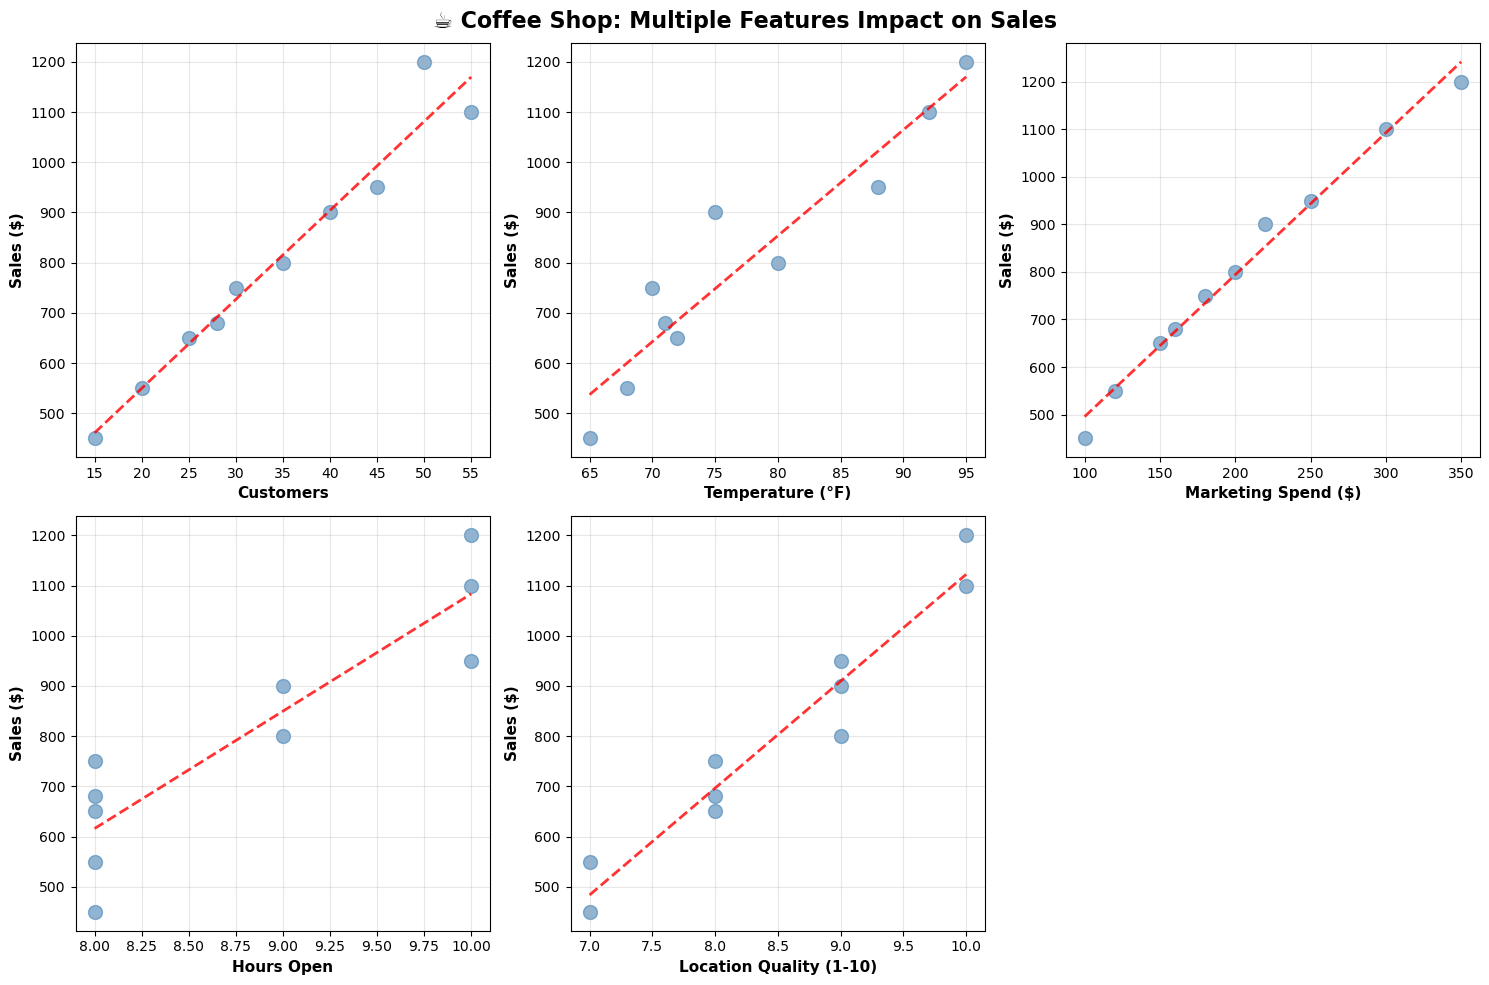


📈 INTERPRETATION:
  - Positive coefficient = Feature increases → Sales increase
  - Negative coefficient = Feature increases → Sales decrease
  - Larger absolute value = Feature has stronger impact



In [49]:
# 2. MULTIPLE FEATURES - COFFEE SHOP
print("\n" + "="*70)
print("☕ COFFEE SHOP: MULTIPLE FEATURES PREDICTION")
print("="*70)
print()

# Create realistic coffee shop data with multiple features
np.random.seed(42)

data = {
    'Customers': [15, 25, 35, 45, 55, 30, 40, 20, 50, 28],
    'Temperature (°F)': [65, 72, 80, 88, 92, 70, 75, 68, 95, 71],
    'Marketing Spend ($)': [100, 150, 200, 250, 300, 180, 220, 120, 350, 160],
    'Hours Open': [8, 8, 9, 10, 10, 8, 9, 8, 10, 8],
    'Location Quality (1-10)': [7, 8, 9, 9, 10, 8, 9, 7, 10, 8],
    'Sales ($)': [450, 650, 800, 950, 1100, 750, 900, 550, 1200, 680]
}

coffee_multi_df = pd.DataFrame(data)

print("\n📊 COFFEE SHOP DATA (Multiple Features):")
print(coffee_multi_df.to_string(index=False))
print()

# Prepare features and target
features = ['Customers', 'Temperature (°F)', 'Marketing Spend ($)', 'Hours Open', 'Location Quality (1-10)']
X_multi = coffee_multi_df[features].values
y_multi = coffee_multi_df['Sales ($)'].values

# Standardize features (important for multiple regression!)
scaler = StandardScaler()
X_multi_scaled = scaler.fit_transform(X_multi)

# Fit model
multi_model = LinearRegression()
multi_model.fit(X_multi_scaled, y_multi)

print("\n🎯 FOUND COEFFICIENTS:")
print(f"  β₀ (Intercept) = {multi_model.intercept_:.2f}")
print()
print("  Feature Coefficients:")
for i, feature in enumerate(features):
    print(f"    β{i+1} ({feature:25s}) = {multi_model.coef_[i]:7.2f}")
print()

# Make predictions
y_pred_multi = multi_model.predict(X_multi_scaled)

print("\n🔮 PREDICTIONS vs ACTUAL:")
results_df = pd.DataFrame({
    'Actual Sales': y_multi,
    'Predicted Sales': y_pred_multi.astype(int),
    'Error': (y_multi - y_pred_multi).astype(int)
})
print(results_df.to_string(index=False))
print()
print(f"✅ R² Score (Accuracy): {multi_model.score(X_multi_scaled, y_multi):.4f}")
print(f"   (1.0 = Perfect fit, 0.0 = No fit)")
print()

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('☕ Coffee Shop: Multiple Features Impact on Sales', fontsize=16, fontweight='bold')

features_to_plot = ['Customers', 'Temperature (°F)', 'Marketing Spend ($)', 'Hours Open', 'Location Quality (1-10)']

for idx, (ax, feature) in enumerate(zip(axes.flat[:5], features_to_plot)):
    ax.scatter(coffee_multi_df[feature], coffee_multi_df['Sales ($)'], s=100, alpha=0.6, color='steelblue')
    
    # Add trend line
    z = np.polyfit(coffee_multi_df[feature], coffee_multi_df['Sales ($)'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(coffee_multi_df[feature].min(), coffee_multi_df[feature].max(), 100)
    ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
    
    ax.set_xlabel(feature, fontsize=11, fontweight='bold')
    ax.set_ylabel('Sales ($)', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

# Remove extra subplot
axes.flat[5].axis('off')

plt.tight_layout()
plt.show()

print("\n📈 INTERPRETATION:")
print("  - Positive coefficient = Feature increases → Sales increase")
print("  - Negative coefficient = Feature increases → Sales decrease")
print("  - Larger absolute value = Feature has stronger impact")
print()
print("="*70)

## <a id="real-estate"></a>6️⃣ REAL ESTATE: Manhattan vs New Jersey


🏠 REAL ESTATE: MANHATTAN vs NEW JERSEY


📊 MANHATTAN:
  Data points: 7
  β₀ (Intercept) = $200000
  β₁ (Slope) = $1200 per sqft
  R² Score = 1.0000

📊 NEW JERSEY:
  Data points: 7
  β₀ (Intercept) = $100000
  β₁ (Slope) = $200 per sqft
  R² Score = 1.0000

🔍 COMPARISON:
  For a 2000 sqft home:
    Manhattan: $2,600,000
    New Jersey: $500,000
    Difference: $2,100,000
    Manhattan is 5.2x more expensive!


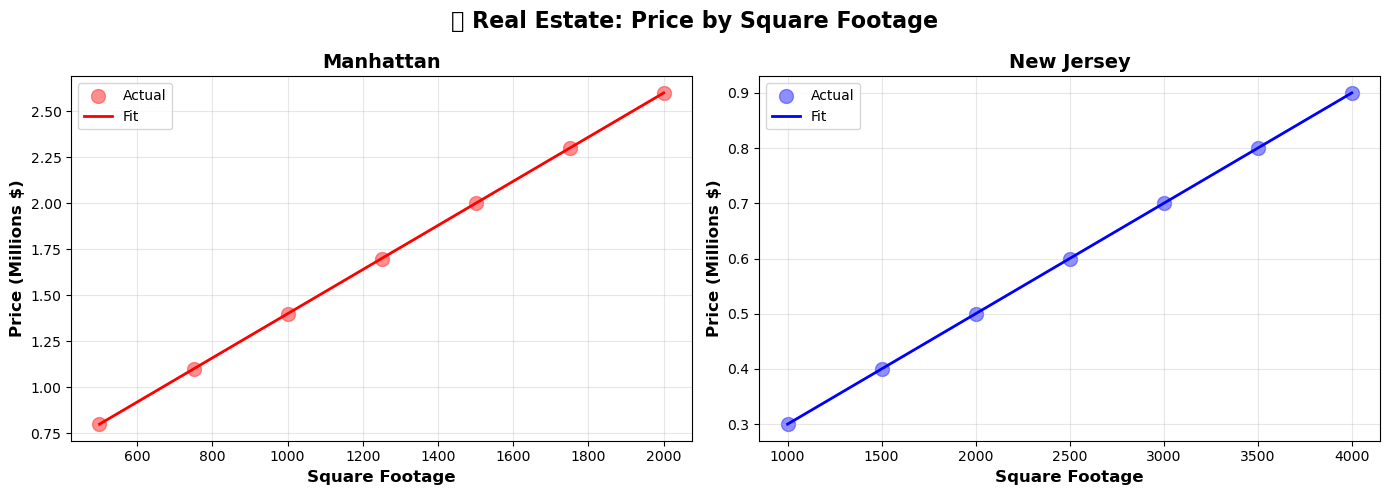


💡 KEY INSIGHT:
  Same square footage = VERY different prices!
  Location matters! Each location has its own slope & intercept.



In [50]:
# 3. REAL ESTATE COMPARISON
print("\n" + "="*70)
print("🏠 REAL ESTATE: MANHATTAN vs NEW JERSEY")
print("="*70)
print()

# Manhattan data
manhattan_sqft = np.array([500, 750, 1000, 1250, 1500, 1750, 2000])
manhattan_prices = np.array([800000, 1100000, 1400000, 1700000, 2000000, 2300000, 2600000])

# New Jersey data
nj_sqft = np.array([1000, 1500, 2000, 2500, 3000, 3500, 4000])
nj_prices = np.array([300000, 400000, 500000, 600000, 700000, 800000, 900000])

# Fit models
X_manhattan = manhattan_sqft.reshape(-1, 1)
y_manhattan = manhattan_prices
manhattan_model = LinearRegression().fit(X_manhattan, y_manhattan)

X_nj = nj_sqft.reshape(-1, 1)
y_nj = nj_prices
nj_model = LinearRegression().fit(X_nj, y_nj)

print("\n📊 MANHATTAN:")
print(f"  Data points: {len(manhattan_sqft)}")
print(f"  β₀ (Intercept) = ${manhattan_model.intercept_:.0f}")
print(f"  β₁ (Slope) = ${manhattan_model.coef_[0]:.0f} per sqft")
print(f"  R² Score = {manhattan_model.score(X_manhattan, y_manhattan):.4f}")

print("\n📊 NEW JERSEY:")
print(f"  Data points: {len(nj_sqft)}")
print(f"  β₀ (Intercept) = ${nj_model.intercept_:.0f}")
print(f"  β₁ (Slope) = ${nj_model.coef_[0]:.0f} per sqft")
print(f"  R² Score = {nj_model.score(X_nj, y_nj):.4f}")

# Comparison
print("\n🔍 COMPARISON:")
example_sqft = 2000
manhattan_pred = manhattan_model.predict([[example_sqft]])[0]
nj_pred = nj_model.predict([[example_sqft]])[0]
print(f"  For a {example_sqft} sqft home:")
print(f"    Manhattan: ${manhattan_pred:,.0f}")
print(f"    New Jersey: ${nj_pred:,.0f}")
print(f"    Difference: ${manhattan_pred - nj_pred:,.0f}")
print(f"    Manhattan is {manhattan_pred / nj_pred:.1f}x more expensive!")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🏠 Real Estate: Price by Square Footage', fontsize=16, fontweight='bold')

# Manhattan
ax1.scatter(manhattan_sqft, manhattan_prices/1e6, s=100, alpha=0.6, color='#FF4444', label='Actual')
x_line = np.linspace(manhattan_sqft.min(), manhattan_sqft.max(), 100)
y_line = manhattan_model.predict(x_line.reshape(-1, 1))
ax1.plot(x_line, y_line/1e6, 'r-', linewidth=2, label='Fit')
ax1.set_xlabel('Square Footage', fontsize=12, fontweight='bold')
ax1.set_ylabel('Price (Millions $)', fontsize=12, fontweight='bold')
ax1.set_title('Manhattan', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# New Jersey
ax2.scatter(nj_sqft, nj_prices/1e6, s=100, alpha=0.6, color='#4444FF', label='Actual')
x_line = np.linspace(nj_sqft.min(), nj_sqft.max(), 100)
y_line = nj_model.predict(x_line.reshape(-1, 1))
ax2.plot(x_line, y_line/1e6, 'b-', linewidth=2, label='Fit')
ax2.set_xlabel('Square Footage', fontsize=12, fontweight='bold')
ax2.set_ylabel('Price (Millions $)', fontsize=12, fontweight='bold')
ax2.set_title('New Jersey', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print("\n💡 KEY INSIGHT:")
print("  Same square footage = VERY different prices!")
print("  Location matters! Each location has its own slope & intercept.")
print()
print("="*70)

## <a id="slopes-viz"></a>7️⃣ VISUALIZING DIFFERENT SLOPES


📊 VISUALIZING DIFFERENT SLOPES



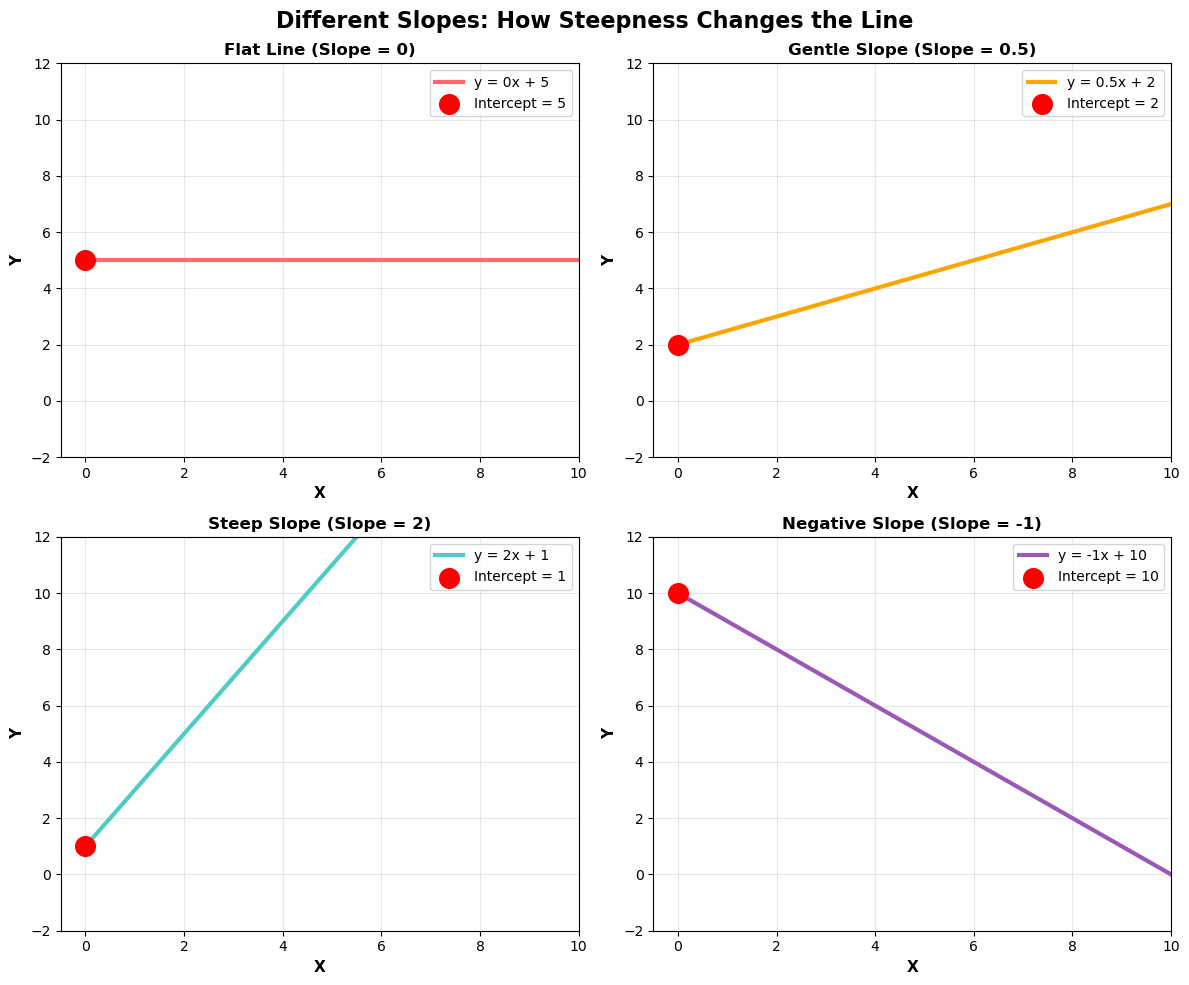


📚 SLOPE MEANINGS:
  • Slope = 0: No relationship (Y stays same as X changes)
  • Slope > 0: Positive relationship (Y increases as X increases)
  • Slope < 0: Negative relationship (Y decreases as X increases)
  • Large slope: Steep line (big changes in Y for small changes in X)
  • Small slope: Gentle line (small changes in Y for changes in X)



In [51]:
# Visualize different slopes
print("\n" + "="*70)
print("📊 VISUALIZING DIFFERENT SLOPES")
print("="*70)
print()

x = np.linspace(0, 10, 100)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Different Slopes: How Steepness Changes the Line', fontsize=16, fontweight='bold')

slopes_info = [
    {'slope': 0, 'intercept': 5, 'title': 'Flat Line (Slope = 0)', 'color': '#FF6B6B'},
    {'slope': 0.5, 'intercept': 2, 'title': 'Gentle Slope (Slope = 0.5)', 'color': '#FFA500'},
    {'slope': 2, 'intercept': 1, 'title': 'Steep Slope (Slope = 2)', 'color': '#4ECDC4'},
    {'slope': -1, 'intercept': 10, 'title': 'Negative Slope (Slope = -1)', 'color': '#9B59B6'}
]

for ax, info in zip(axes.flat, slopes_info):
    y = info['slope'] * x + info['intercept']
    
    ax.plot(x, y, linewidth=3, color=info['color'], label=f"y = {info['slope']}x + {info['intercept']}")
    ax.scatter([0], [info['intercept']], s=200, color='red', zorder=5, label=f"Intercept = {info['intercept']}")
    
    ax.set_xlabel('X', fontsize=11, fontweight='bold')
    ax.set_ylabel('Y', fontsize=11, fontweight='bold')
    ax.set_title(info['title'], fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    ax.set_xlim(-0.5, 10)
    ax.set_ylim(-2, 12)

plt.tight_layout()
plt.show()

print("\n📚 SLOPE MEANINGS:")
print("  • Slope = 0: No relationship (Y stays same as X changes)")
print("  • Slope > 0: Positive relationship (Y increases as X increases)")
print("  • Slope < 0: Negative relationship (Y decreases as X increases)")
print("  • Large slope: Steep line (big changes in Y for small changes in X)")
print("  • Small slope: Gentle line (small changes in Y for changes in X)")
print()
print("="*70)

# PART 3: ADVANCED TOPICS 🚀

## <a id="overfitting"></a>8️⃣ OVERFITTING vs UNDERFITTING


⚠️ OVERFITTING vs UNDERFITTING


📊 MODEL PERFORMANCE COMPARISON:

UNDERFITTING (Degree 1 - Too Simple):
  Train R² = 0.8442 (BOTH LOW - Problem! ❌)
  Test R²  = -0.2160

PERFECT FIT (Degree 2 - Just Right):
  Train R² = 0.8497 (BOTH HIGH & Similar - Good! ✅)
  Test R²  = -0.1627

OVERFITTING (Degree 10 - Too Complex):
  Train R² = 0.8895 (Train HIGH but Test LOW - Problem! ❌)
  Test R²  = -13390.9169



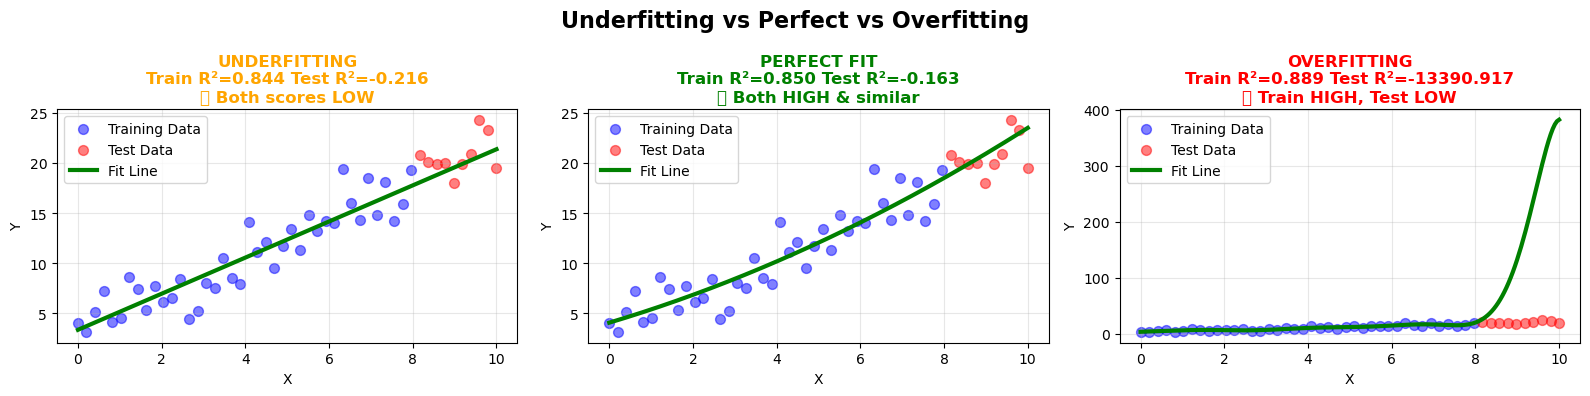


🎯 HOW TO DETECT:
  UNDERFITTING:  Train Score LOW + Test Score LOW → Model too simple
  PERFECT:       Train Score HIGH + Test Score HIGH (similar) → Goldilocks zone!
  OVERFITTING:   Train Score HIGH + Test Score LOW → Model memorized data



In [52]:
# OVERFITTING vs UNDERFITTING
print("\n" + "="*70)
print("⚠️ OVERFITTING vs UNDERFITTING")
print("="*70)
print()

# Generate synthetic data
np.random.seed(42)
X_demo = np.linspace(0, 10, 50).reshape(-1, 1)
y_demo = 3 + 2*X_demo.flatten() + np.random.normal(0, 2, 50)

# Split data
split_idx = 40
X_train_demo, X_test_demo = X_demo[:split_idx], X_demo[split_idx:]
y_train_demo, y_test_demo = y_demo[:split_idx], y_demo[split_idx:]

# Three models with different complexity
# Underfitting: degree 1 (too simple)
poly_under = PolynomialFeatures(degree=1)
X_train_under = poly_under.fit_transform(X_train_demo)
X_test_under = poly_under.transform(X_test_demo)
model_under = LinearRegression().fit(X_train_under, y_train_demo)

# Perfect: degree 2 (just right)
poly_perfect = PolynomialFeatures(degree=2)
X_train_perfect = poly_perfect.fit_transform(X_train_demo)
X_test_perfect = poly_perfect.transform(X_test_demo)
model_perfect = LinearRegression().fit(X_train_perfect, y_train_demo)

# Overfitting: degree 10 (too complex)
poly_over = PolynomialFeatures(degree=10)
X_train_over = poly_over.fit_transform(X_train_demo)
X_test_over = poly_over.transform(X_test_demo)
model_over = LinearRegression().fit(X_train_over, y_train_demo)

# Calculate scores
train_score_under = model_under.score(X_train_under, y_train_demo)
test_score_under = model_under.score(X_test_under, y_test_demo)

train_score_perfect = model_perfect.score(X_train_perfect, y_train_demo)
test_score_perfect = model_perfect.score(X_test_perfect, y_test_demo)

train_score_over = model_over.score(X_train_over, y_train_demo)
test_score_over = model_over.score(X_test_over, y_test_demo)

print("\n📊 MODEL PERFORMANCE COMPARISON:")
print()
print("UNDERFITTING (Degree 1 - Too Simple):")
print(f"  Train R² = {train_score_under:.4f} (BOTH LOW - Problem! ❌)")
print(f"  Test R²  = {test_score_under:.4f}")
print()
print("PERFECT FIT (Degree 2 - Just Right):")
print(f"  Train R² = {train_score_perfect:.4f} (BOTH HIGH & Similar - Good! ✅)")
print(f"  Test R²  = {test_score_perfect:.4f}")
print()
print("OVERFITTING (Degree 10 - Too Complex):")
print(f"  Train R² = {train_score_over:.4f} (Train HIGH but Test LOW - Problem! ❌)")
print(f"  Test R²  = {test_score_over:.4f}")
print()

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Underfitting vs Perfect vs Overfitting', fontsize=16, fontweight='bold')

x_smooth = np.linspace(0, 10, 200).reshape(-1, 1)

# Underfitting
axes[0].scatter(X_train_demo, y_train_demo, s=50, alpha=0.5, label='Training Data', color='blue')
axes[0].scatter(X_test_demo, y_test_demo, s=50, alpha=0.5, label='Test Data', color='red')
x_smooth_under = poly_under.transform(x_smooth)
y_smooth_under = model_under.predict(x_smooth_under)
axes[0].plot(x_smooth, y_smooth_under, 'g-', linewidth=3, label='Fit Line')
axes[0].set_title(f'UNDERFITTING\nTrain R²={train_score_under:.3f} Test R²={test_score_under:.3f}\n❌ Both scores LOW', fontweight='bold', color='orange')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Perfect
axes[1].scatter(X_train_demo, y_train_demo, s=50, alpha=0.5, label='Training Data', color='blue')
axes[1].scatter(X_test_demo, y_test_demo, s=50, alpha=0.5, label='Test Data', color='red')
x_smooth_perfect = poly_perfect.transform(x_smooth)
y_smooth_perfect = model_perfect.predict(x_smooth_perfect)
axes[1].plot(x_smooth, y_smooth_perfect, 'g-', linewidth=3, label='Fit Line')
axes[1].set_title(f'PERFECT FIT\nTrain R²={train_score_perfect:.3f} Test R²={test_score_perfect:.3f}\n✅ Both HIGH & similar', fontweight='bold', color='green')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Overfitting
axes[2].scatter(X_train_demo, y_train_demo, s=50, alpha=0.5, label='Training Data', color='blue')
axes[2].scatter(X_test_demo, y_test_demo, s=50, alpha=0.5, label='Test Data', color='red')
x_smooth_over = poly_over.transform(x_smooth)
y_smooth_over = model_over.predict(x_smooth_over)
axes[2].plot(x_smooth, y_smooth_over, 'g-', linewidth=3, label='Fit Line')
axes[2].set_title(f'OVERFITTING\nTrain R²={train_score_over:.3f} Test R²={test_score_over:.3f}\n❌ Train HIGH, Test LOW', fontweight='bold', color='red')
axes[2].set_xlabel('X')
axes[2].set_ylabel('Y')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🎯 HOW TO DETECT:")
print("  UNDERFITTING:  Train Score LOW + Test Score LOW → Model too simple")
print("  PERFECT:       Train Score HIGH + Test Score HIGH (similar) → Goldilocks zone!")
print("  OVERFITTING:   Train Score HIGH + Test Score LOW → Model memorized data")
print()
print("="*70)

## <a id="regularization"></a>9️⃣ REGULARIZATION TECHNIQUES

**How to Fix Overfitting?**

Use **Regularization**: Add a penalty for complex models.

Three main techniques:

### 1. Ridge Regression (L2 Penalty)
- **What it does:** Shrinks coefficient values (makes them smaller)
- **Formula:** Adds λ × (sum of squared coefficients) to cost function
- **Effect:** All features kept, but with smaller impact
- **Use when:** Many features, want to keep all

### 2. Lasso Regression (L1 Penalty)
- **What it does:** Removes weak features entirely (sets coefficient to 0)
- **Formula:** Adds λ × (sum of absolute coefficients) to cost function
- **Effect:** Some features completely removed
- **Use when:** Many features, want feature selection

### 3. ElasticNet (L1 + L2)
- **What it does:** Combination of Ridge and Lasso
- **Effect:** Shrinks some, removes others
- **Use when:** Want benefits of both methods

In [53]:
# REGULARIZATION COMPARISON
print("\n" + "="*70)
print("🎯 REGULARIZATION: Ridge vs Lasso vs ElasticNet")
print("="*70)
print()

# Generate synthetic data (if not already created from Overfitting section)
if 'X_train_demo' not in locals():
    np.random.seed(42)
    X_demo = np.linspace(0, 10, 50).reshape(-1, 1)
    y_demo = 3 + 2*X_demo.flatten() + np.random.normal(0, 2, 50)
    
    # Split data
    split_idx = 40
    X_train_demo, X_test_demo = X_demo[:split_idx], X_demo[split_idx:]
    y_train_demo, y_test_demo = y_demo[:split_idx], y_demo[split_idx:]

# Prepare data with polynomial features
poly_reg = PolynomialFeatures(degree=3)
X_train_reg = poly_reg.fit_transform(X_train_demo)
X_test_reg = poly_reg.transform(X_test_demo)

# Standardize (important for regularization!)
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

# Train models
lambda_val = 1.0

ridge_model = Ridge(alpha=lambda_val).fit(X_train_reg_scaled, y_train_demo)
lasso_model = Lasso(alpha=lambda_val).fit(X_train_reg_scaled, y_train_demo)
elastic_model = ElasticNet(alpha=lambda_val, l1_ratio=0.5).fit(X_train_reg_scaled, y_train_demo)

# Get coefficients
ridge_coef = ridge_model.coef_
lasso_coef = lasso_model.coef_
elastic_coef = elastic_model.coef_

print("\n📊 MODEL PERFORMANCE:")
print()
print("RIDGE REGRESSION (L2 Penalty):")
ridge_train = ridge_model.score(X_train_reg_scaled, y_train_demo)
ridge_test = ridge_model.score(X_test_reg_scaled, y_test_demo)
print(f"  Train R² = {ridge_train:.4f}")
print(f"  Test R²  = {ridge_test:.4f}")
print(f"  Coefficient sum = {np.sum(np.abs(ridge_coef)):.2f} (Shrunk but not zeroed)")
n_zeros_r = np.sum(ridge_coef == 0)
print(f"  Zeros: {n_zeros_r} coefficients")
print()

print("LASSO REGRESSION (L1 Penalty):")
lasso_train = lasso_model.score(X_train_reg_scaled, y_train_demo)
lasso_test = lasso_model.score(X_test_reg_scaled, y_test_demo)
print(f"  Train R² = {lasso_train:.4f}")
print(f"  Test R²  = {lasso_test:.4f}")
print(f"  Coefficient sum = {np.sum(np.abs(lasso_coef)):.2f} (Some zeroed out!)")
n_zeros_l = np.sum(lasso_coef == 0)
print(f"  Zeros: {n_zeros_l} coefficients (Features removed!)")
print()

print("ELASTICNET (L1 + L2):")
elastic_train = elastic_model.score(X_train_reg_scaled, y_train_demo)
elastic_test = elastic_model.score(X_test_reg_scaled, y_test_demo)
print(f"  Train R² = {elastic_train:.4f}")
print(f"  Test R²  = {elastic_test:.4f}")
print(f"  Coefficient sum = {np.sum(np.abs(elastic_coef)):.2f} (Balanced approach)")
n_zeros_e = np.sum(elastic_coef == 0)
print(f"  Zeros: {n_zeros_e} coefficients")
print()

# Comparison table
comparison_df = pd.DataFrame({
    'Model': ['Ridge', 'Lasso', 'ElasticNet'],
    'Train R²': [ridge_train, lasso_train, elastic_train],
    'Test R²': [ridge_test, lasso_test, elastic_test],
    'Coef Sum': [np.sum(np.abs(ridge_coef)), np.sum(np.abs(lasso_coef)), np.sum(np.abs(elastic_coef))],
    'Zeros': [n_zeros_r, n_zeros_l, n_zeros_e]
})
print("\n📋 COMPARISON TABLE:")
print(comparison_df.to_string(index=False))
print()
print("="*70)


🎯 REGULARIZATION: Ridge vs Lasso vs ElasticNet


📊 MODEL PERFORMANCE:

RIDGE REGRESSION (L2 Penalty):
  Train R² = 0.8492
  Test R²  = -0.2864
  Coefficient sum = 4.23 (Shrunk but not zeroed)
  Zeros: 1 coefficients

LASSO REGRESSION (L1 Penalty):
  Train R² = 0.8020
  Test R²  = -1.5355
  Coefficient sum = 3.27 (Some zeroed out!)
  Zeros: 2 coefficients (Features removed!)

ELASTICNET (L1 + L2):
  Train R² = 0.7826
  Test R²  = -0.2903
  Coefficient sum = 3.20 (Balanced approach)
  Zeros: 1 coefficients


📋 COMPARISON TABLE:
     Model  Train R²   Test R²  Coef Sum  Zeros
     Ridge  0.849243 -0.286397  4.231354      1
     Lasso  0.802014 -1.535528  3.268270      2
ElasticNet  0.782597 -0.290290  3.200746      1



## <a id="metrics"></a>🔟 EVALUATION METRICS

**How do we know if our model is good?**

We use different metrics depending on the problem:

| Metric | Formula | Range | When to Use |
|--------|---------|-------|-------------|
| **MSE** (Mean Squared Error) | $\frac{1}{n}\sum(y - \hat{y})^2$ | 0 to ∞ | Penalizes large errors heavily |
| **RMSE** (Root MSE) | $\sqrt{MSE}$ | 0 to ∞ | Back in original units |
| **MAE** (Mean Absolute Error) | $\frac{1}{n}\sum|y - \hat{y}|$ | 0 to ∞ | Robust to outliers |
| **R²** (R-squared) | $1 - \frac{SS_{res}}{SS_{tot}}$ | 0 to 1 | % of variance explained |

### Key Insights:
- **MSE/RMSE/MAE:** Lower is better
- **R²:** Higher is better (1.0 = perfect, 0.0 = no fit)

In [54]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# EVALUATION METRICS
print("\n" + "="*70)
print("📏 EVALUATION METRICS")
print("="*70)
print()

# Simple model predictions
y_pred_simple = model_perfect.predict(X_test_perfect)
y_pred_ridge = ridge_model.predict(X_test_reg_scaled)
y_pred_lasso = lasso_model.predict(X_test_reg_scaled)
y_pred_elastic = elastic_model.predict(X_test_reg_scaled)

# Calculate metrics
def calc_metrics(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = 1 - (np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2))
    
    print(f"\n{model_name}:")
    print(f"  MSE  (Mean Squared Error)   = {mse:.4f}")
    print(f"  RMSE (Root MSE)            = {rmse:.4f}")
    print(f"  MAE  (Mean Absolute Error) = {mae:.4f}")
    print(f"  R²   (R-squared)           = {r2:.4f}")
    
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R²': r2}

metrics_simple = calc_metrics(y_test_demo, y_pred_simple, "Simple Model (Degree 2)")
metrics_ridge = calc_metrics(y_test_demo, y_pred_ridge, "Ridge Regression")
metrics_lasso = calc_metrics(y_test_demo, y_pred_lasso, "Lasso Regression")
metrics_elastic = calc_metrics(y_test_demo, y_pred_elastic, "ElasticNet")

# Create comparison table
metrics_df = pd.DataFrame({
    'Model': ['Simple', 'Ridge', 'Lasso', 'ElasticNet'],
    'MSE': [metrics_simple['MSE'], metrics_ridge['MSE'], metrics_lasso['MSE'], metrics_elastic['MSE']],
    'RMSE': [metrics_simple['RMSE'], metrics_ridge['RMSE'], metrics_lasso['RMSE'], metrics_elastic['RMSE']],
    'MAE': [metrics_simple['MAE'], metrics_ridge['MAE'], metrics_lasso['MAE'], metrics_elastic['MAE']],
    'R²': [metrics_simple['R²'], metrics_ridge['R²'], metrics_lasso['R²'], metrics_elastic['R²']]
})

print("\n📋 METRICS COMPARISON TABLE:")
print(metrics_df.to_string(index=False))
print()
print("✅ INTERPRETATION:")
print("   Lower MSE/RMSE/MAE = Better predictions")
print("   Higher R² = More variance explained (max 1.0)")
print()
print("="*70)


📏 EVALUATION METRICS


Simple Model (Degree 2):
  MSE  (Mean Squared Error)   = 3.5537
  RMSE (Root MSE)            = 1.8851
  MAE  (Mean Absolute Error) = 1.4676
  R²   (R-squared)           = -0.1627

Ridge Regression:
  MSE  (Mean Squared Error)   = 3.9319
  RMSE (Root MSE)            = 1.9829
  MAE  (Mean Absolute Error) = 1.5074
  R²   (R-squared)           = -0.2864

Lasso Regression:
  MSE  (Mean Squared Error)   = 7.7498
  RMSE (Root MSE)            = 2.7838
  MAE  (Mean Absolute Error) = 2.3990
  R²   (R-squared)           = -1.5355

ElasticNet:
  MSE  (Mean Squared Error)   = 3.9438
  RMSE (Root MSE)            = 1.9859
  MAE  (Mean Absolute Error) = 1.6588
  R²   (R-squared)           = -0.2903

📋 METRICS COMPARISON TABLE:
     Model      MSE     RMSE      MAE        R²
    Simple 3.553672 1.885119 1.467617 -0.162664
     Ridge 3.931862 1.982892 1.507410 -0.286397
     Lasso 7.749819 2.783850 2.399022 -1.535528
ElasticNet 3.943760 1.985890 1.658837 -0.290290

✅ INTERPRETATI

## <a id="hypothesis-testing"></a>1️⃣1️⃣ HYPOTHESIS TESTING

**Is the relationship real or just by chance?**

We use statistical tests to find out!

### Common Tests:
1. **Pearson Correlation Test** - Is X and Y related?
2. **t-test** - Are two groups significantly different?
3. **Shapiro-Wilk Test** - Is data normally distributed?
4. **p-value** - Probability that result is by chance (< 0.05 = significant)

In [55]:
from scipy.stats import pearsonr, spearmanr, ttest_ind, shapiro

# HYPOTHESIS TESTING
print("\n" + "="*70)
print("🧪 HYPOTHESIS TESTING")
print("="*70)
print()

# Test 1: Correlation
print("\nTEST 1️⃣: IS THERE A CORRELATION?")
print("-" * 70)
pearson_r, pearson_p = pearsonr(X_demo.flatten(), y_demo)
print(f"Pearson Correlation:")
print(f"  r = {pearson_r:.4f} (correlation strength)")
print(f"  p-value = {pearson_p:.8f}")
if pearson_p < 0.05:
    print(f"  ✅ SIGNIFICANT! (p < 0.05) - Strong evidence of correlation")
else:
    print(f"  ❌ NOT significant (p ≥ 0.05) - Could be by chance")

spearman_r, spearman_p = spearmanr(X_demo.flatten(), y_demo)
print(f"\nSpearman Correlation:")
print(f"  ρ = {spearman_r:.4f}")
print(f"  p-value = {spearman_p:.8f}")

# Test 2: Group Comparison
print("\n\nTEST 2️⃣: ARE MANHATTAN AND NJ PRICES DIFFERENT?")
print("-" * 70)
t_stat, t_pval = ttest_ind(manhattan_prices, nj_prices)
print(f"Independent t-test:")
print(f"  t-statistic = {t_stat:.4f}")
print(f"  p-value = {t_pval:.8f}")
if t_pval < 0.05:
    print(f"  ✅ SIGNIFICANT! (p < 0.05) - Prices ARE significantly different!")
else:
    print(f"  ❌ NOT significant - Could be by chance")

# Test 3: Normality
print("\n\nTEST 3️⃣: IS DATA NORMALLY DISTRIBUTED?")
print("-" * 70)
shapiro_stat, shapiro_p = shapiro(y_demo)
print(f"Shapiro-Wilk Test:")
print(f"  Statistic = {shapiro_stat:.4f}")
print(f"  p-value = {shapiro_p:.8f}")
if shapiro_p > 0.05:
    print(f"  ✅ YES! (p > 0.05) - Data is normally distributed")
else:
    print(f"  ❌ NO - Data is NOT normally distributed")

print("\n\n📚 P-VALUE INTERPRETATION:")
print("-" * 70)
print("p-value < 0.05: ✅ Result is STATISTICALLY SIGNIFICANT (real effect)")
print("p-value ≥ 0.05: ❌ Result NOT significant (could be by chance)")
print()
print("="*70)


🧪 HYPOTHESIS TESTING


TEST 1️⃣: IS THERE A CORRELATION?
----------------------------------------------------------------------
Pearson Correlation:
  r = 0.9504 (correlation strength)
  p-value = 0.00000000
  ✅ SIGNIFICANT! (p < 0.05) - Strong evidence of correlation

Spearman Correlation:
  ρ = 0.9514
  p-value = 0.00000000


TEST 2️⃣: ARE MANHATTAN AND NJ PRICES DIFFERENT?
----------------------------------------------------------------------
Independent t-test:
  t-statistic = 4.2603
  p-value = 0.00110696
  ✅ SIGNIFICANT! (p < 0.05) - Prices ARE significantly different!


TEST 3️⃣: IS DATA NORMALLY DISTRIBUTED?
----------------------------------------------------------------------
Shapiro-Wilk Test:
  Statistic = 0.9485
  p-value = 0.02954173
  ❌ NO - Data is NOT normally distributed


📚 P-VALUE INTERPRETATION:
----------------------------------------------------------------------
p-value < 0.05: ✅ Result is STATISTICALLY SIGNIFICANT (real effect)
p-value ≥ 0.05: ❌ Result NOT sig

## <a id="categorical"></a>1️⃣2️⃣ CATEGORICAL DATA & ENCODING

**What if your data has text (categories) instead of numbers?**

### Problem:
Linear regression needs NUMBERS, but sometimes we have:
- Colors: Red, Blue, Green
- Neighborhoods: Manhattan, Brooklyn, Queens
- Days: Monday, Tuesday, Wednesday

### Solution: **ENCODING** (Convert text to numbers)

### Method 1: Label Encoding
- Maps categories to integers: Red=0, Blue=1, Green=2
- **Use when:** Categories have natural order (Small, Medium, Large)

### Method 2: One-Hot Encoding  
- Creates binary columns for each category
- Red = [1, 0, 0], Blue = [0, 1, 0], Green = [0, 0, 1]
- **Use when:** Categories have NO natural order (Colors, Cities)

In [56]:
# CATEGORICAL ENCODING
print("\n" + "="*70)
print("🏷️ CATEGORICAL DATA & ENCODING")
print("="*70)
print()

# Create sample data
data_cat = {
    'Neighborhood': ['Manhattan', 'Brooklyn', 'Queens', 'Manhattan', 'Brooklyn', 'Queens', 
                     'Manhattan', 'Brooklyn', 'Queens', 'Manhattan'],
    'House_Color': ['Red', 'Blue', 'Green', 'White', 'Red', 'Blue', 'Green', 'White', 'Red', 'Blue'],
    'Size_Category': ['Small', 'Medium', 'Large', 'Medium', 'Large', 'Small', 'Large', 'Medium', 'Small', 'Medium'],
    'Square_Feet': [800, 1200, 2000, 1400, 1800, 900, 2200, 1300, 1000, 1500],
    'Price ($)': [300000, 450000, 750000, 500000, 700000, 350000, 850000, 480000, 380000, 600000]
}

df_cat = pd.DataFrame(data_cat)

print("\n📊 ORIGINAL DATA (With Text):")
print(df_cat.to_string(index=False))
print()

# METHOD 1: LABEL ENCODING
print("\n" + "="*70)
print("METHOD 1️⃣: LABEL ENCODING (Map to integers)")
print("="*70)
print()

df_label = df_cat.copy()

le_neighborhood = LabelEncoder()
le_color = LabelEncoder()
le_size = LabelEncoder()

df_label['Neighborhood'] = le_neighborhood.fit_transform(df_cat['Neighborhood'])
df_label['House_Color'] = le_color.fit_transform(df_cat['House_Color'])
df_label['Size_Category'] = le_size.fit_transform(df_cat['Size_Category'])

print("Encoding Mappings:")
print(f"  Neighborhoods: {dict(zip(le_neighborhood.classes_, le_neighborhood.transform(le_neighborhood.classes_)))}")
print(f"  Colors: {dict(zip(le_color.classes_, le_color.transform(le_color.classes_)))}")
print(f"  Size: {dict(zip(le_size.classes_, le_size.transform(le_size.classes_)))}")
print()
print("Encoded Data:")
print(df_label.to_string(index=False))
print()

# METHOD 2: ONE-HOT ENCODING
print("\n" + "="*70)
print("METHOD 2️⃣: ONE-HOT ENCODING (Create binary columns)")
print("="*70)
print()

df_onehot = df_cat.copy()

# One-hot encode
neighborhood_onehot = pd.get_dummies(df_cat['Neighborhood'], prefix='Neighborhood')
color_onehot = pd.get_dummies(df_cat['House_Color'], prefix='Color')

# Combine
df_onehot = df_onehot.drop(['Neighborhood', 'House_Color'], axis=1)
df_onehot = pd.concat([df_onehot, neighborhood_onehot, color_onehot], axis=1)

print("One-Hot Encoded Data:")
print(df_onehot.to_string(index=False))
print()

print("\n📚 WHEN TO USE:")
print("-" * 70)
print("Label Encoding: ✅ When categories have natural order")
print("  Example: Small < Medium < Large, Low < Medium < High")
print()
print("One-Hot Encoding: ✅ When categories have NO natural order")
print("  Example: Colors (Red/Blue/Green), Cities (Manhattan/Brooklyn/Queens)")
print()
print("="*70)


🏷️ CATEGORICAL DATA & ENCODING


📊 ORIGINAL DATA (With Text):
Neighborhood House_Color Size_Category  Square_Feet  Price ($)
   Manhattan         Red         Small          800     300000
    Brooklyn        Blue        Medium         1200     450000
      Queens       Green         Large         2000     750000
   Manhattan       White        Medium         1400     500000
    Brooklyn         Red         Large         1800     700000
      Queens        Blue         Small          900     350000
   Manhattan       Green         Large         2200     850000
    Brooklyn       White        Medium         1300     480000
      Queens         Red         Small         1000     380000
   Manhattan        Blue        Medium         1500     600000


METHOD 1️⃣: LABEL ENCODING (Map to integers)

Encoding Mappings:
  Neighborhoods: {'Brooklyn': 0, 'Manhattan': 1, 'Queens': 2}
  Colors: {'Blue': 0, 'Green': 1, 'Red': 2, 'White': 3}
  Size: {'Large': 0, 'Medium': 1, 'Small': 2}

Encoded Data

# PART 4: MACHINE LEARNING 🤖

## <a id="gradient-descent"></a>1️⃣3️⃣ GRADIENT DESCENT: The Algorithm That Powers Machine Learning

**How does machine learning actually "learn"?**

### The Algorithm:
1. Start with random coefficients (β₀ and β₁)
2. Calculate error (how far off predictions are)
3. Calculate gradient (which direction to go)
4. Move coefficients in the right direction
5. Repeat steps 2-4 many times

### Key Parameters:
- **Learning Rate:** How big a step to take (too small = slow, too big = skip the answer)
- **Epochs:** How many times to repeat the loop

### Result:
**Coefficients converge to optimal values!**

In [57]:
# GRADIENT DESCENT
print("\n" + "="*70)
print("🚀 GRADIENT DESCENT: How Machine Learning Learns")
print("="*70)
print()

# Use our coffee data
X_gd = customers.reshape(-1, 1)
y_gd = sales

# Normalize data
X_gd_norm = (X_gd - X_gd.mean()) / X_gd.std()
y_gd_norm = (y_gd - y_gd.mean()) / y_gd.std()

# Gradient Descent Implementation
def gradient_descent(X, y, learning_rate=0.1, epochs=50):
    m = len(X)
    b0 = 0  # Intercept
    b1 = 0  # Slope
    
    costs = []
    b0_hist = []
    b1_hist = []
    
    for epoch in range(epochs):
        # Predictions
        y_pred = b0 + b1 * X.flatten()
        
        # Errors
        errors = y - y_pred
        
        # Cost (MSE)
        cost = np.sum(errors**2) / m
        costs.append(cost)
        
        # Gradients
        db0 = -2 * np.sum(errors) / m
        db1 = -2 * np.sum(errors * X.flatten()) / m
        
        # Update coefficients
        b0 = b0 - learning_rate * db0
        b1 = b1 - learning_rate * db1
        
        b0_hist.append(b0)
        b1_hist.append(b1)
        
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch:2d}: Cost = {cost:.6f}, b0 = {b0:.6f}, b1 = {b1:.6f}")
    
    return b0, b1, costs, b0_hist, b1_hist

print("\n📊 GRADIENT DESCENT PROGRESS:")
print("-" * 70)
b0_gd, b1_gd, costs, b0_hist, b1_hist = gradient_descent(X_gd_norm, y_gd_norm, learning_rate=0.1, epochs=50)

print()
print(f"\n🎯 FINAL COEFFICIENTS:")
print(f"  b0 (Intercept) = {b0_gd:.6f}")
print(f"  b1 (Slope) = {b1_gd:.6f}")
print()

# Compare with sklearn
sk_model_gd = LinearRegression().fit(X_gd_norm, y_gd_norm)
print(f"\n✅ VERIFICATION (sklearn LinearRegression):")
print(f"  b0 = {sk_model_gd.intercept_:.6f} (Our GD: {b0_gd:.6f}) ✓")
print(f"  b1 = {sk_model_gd.coef_[0]:.6f} (Our GD: {b1_gd:.6f}) ✓")
print()
print("🎉 Our gradient descent found the same coefficients as sklearn!")
print()
print("="*70)


🚀 GRADIENT DESCENT: How Machine Learning Learns


📊 GRADIENT DESCENT PROGRESS:
----------------------------------------------------------------------
Epoch  0: Cost = 1.000000, b0 = 0.000000, b1 = 0.200000
Epoch  9: Cost = 0.018014, b0 = 0.000000, b1 = 0.892626
Epoch 19: Cost = 0.000208, b0 = 0.000000, b1 = 0.988471
Epoch 29: Cost = 0.000002, b0 = 0.000000, b1 = 0.998762
Epoch 39: Cost = 0.000000, b0 = 0.000000, b1 = 0.999867
Epoch 49: Cost = 0.000000, b0 = 0.000000, b1 = 0.999986


🎯 FINAL COEFFICIENTS:
  b0 (Intercept) = 0.000000
  b1 (Slope) = 0.999986


✅ VERIFICATION (sklearn LinearRegression):
  b0 = 0.000000 (Our GD: 0.000000) ✓
  b1 = 1.000000 (Our GD: 0.999986) ✓

🎉 Our gradient descent found the same coefficients as sklearn!



## <a id="learning"></a>1️⃣4️⃣ GRADIENT DESCENT VISUALIZATION

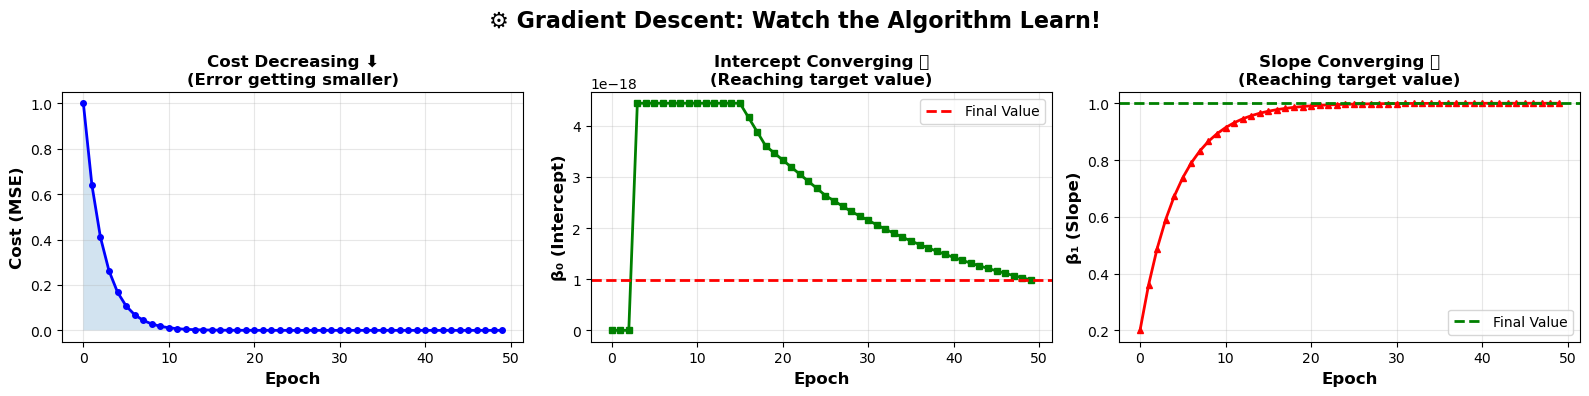


🔍 WHAT'S HAPPENING:
----------------------------------------------------------------------
LEFT:   Cost is decreasing (error getting smaller)
CENTER: Intercept (b0) is converging to optimal value
RIGHT:  Slope (b1) is converging to optimal value

🎯 RESULT: Machine learning found the best fit line!



In [58]:
# VISUALIZE GRADIENT DESCENT CONVERGENCE
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('⚙️ Gradient Descent: Watch the Algorithm Learn!', fontsize=16, fontweight='bold')

epochs_range = range(len(costs))

# Cost over time
axes[0].plot(epochs_range, costs, 'b-', linewidth=2, marker='o', markersize=4)
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cost (MSE)', fontsize=12, fontweight='bold')
axes[0].set_title('Cost Decreasing ⬇️\n(Error getting smaller)', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].fill_between(epochs_range, costs, alpha=0.2)

# Intercept convergence
axes[1].plot(epochs_range, b0_hist, 'g-', linewidth=2, marker='s', markersize=4)
axes[1].axhline(y=b0_gd, color='r', linestyle='--', linewidth=2, label='Final Value')
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('β₀ (Intercept)', fontsize=12, fontweight='bold')
axes[1].set_title('Intercept Converging 🎯\n(Reaching target value)', fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Slope convergence
axes[2].plot(epochs_range, b1_hist, 'r-', linewidth=2, marker='^', markersize=4)
axes[2].axhline(y=b1_gd, color='g', linestyle='--', linewidth=2, label='Final Value')
axes[2].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[2].set_ylabel('β₁ (Slope)', fontsize=12, fontweight='bold')
axes[2].set_title('Slope Converging 🎯\n(Reaching target value)', fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

print("\n🔍 WHAT'S HAPPENING:")
print("-" * 70)
print("LEFT:   Cost is decreasing (error getting smaller)")
print("CENTER: Intercept (b0) is converging to optimal value")
print("RIGHT:  Slope (b1) is converging to optimal value")
print()
print("🎯 RESULT: Machine learning found the best fit line!")
print()

# PART 5: REFERENCES & RESOURCES 🔗

## <a id="references"></a>1️⃣5️⃣ REFERENCES & FURTHER READING

### 📚 Recommended Books

1. **"An Introduction to Statistical Learning"** by James, Witten, Hastie, Tibshirani
   - Perfect for beginners
   - With R code examples
   - Free PDF available: https://www.statlearning.com/

2. **"The Hundred-Page Machine Learning Book"** by Andriy Burkov
   - Concise overview of ML concepts
   - Great for quick reference

3. **"Hands-On Machine Learning"** by Aurélien Géron
   - Practical approach with Python
   - Real-world examples

### 🔗 Online Resources

- **Scikit-learn Documentation** https://scikit-learn.org/
  - Official ML library for Python
  - Comprehensive examples

- **StatQuest with Josh Starmer** https://www.youtube.com/c/joshstarmer
  - YouTube channel with excellent ML explanations
  - Easy to understand videos

- **3Blue1Brown - Essence of Linear Algebra** https://www.youtube.com/c/3blue1brown
  - Beautiful visualizations of linear algebra
  - Great for understanding foundations

- **Kaggle** https://www.kaggle.com/
  - Datasets and competitions
  - Community notebooks with examples

### 📊 Papers

- **"Regularization and Variable Selection via the Elastic Net"** by Zou & Hastie (2005)
  - Original ElasticNet paper

- **"Regression Shrinkage and Selection via the Lasso"** by Tibshirani (1996)
  - Original Lasso paper

### 💻 Python Libraries

- **Scikit-learn** - Machine learning algorithms
- **NumPy** - Numerical computing
- **Pandas** - Data manipulation
- **Matplotlib** - Visualization
- **Seaborn** - Statistical visualizations
- **SciPy** - Scientific computing & statistics

## <a id="quick-ref"></a>1️⃣6️⃣ QUICK REFERENCE GUIDE

### 🎯 Quick Decision Tree

**Q: Is my model predicting well on test data?**
- YES → ✅ Great! You're done!
- NO → Continue below

**Q: Is train score HIGH but test score LOW? (Overfitting)**
- YES → Use regularization (Ridge/Lasso)
- NO → Continue below

**Q: Are both train and test scores LOW? (Underfitting)**
- YES → Add more features or increase complexity
- NO → You might be fine!

### 📋 When to Use Each Technique

| Situation | Solution |
|-----------|----------|
| Too many features | Use Lasso (removes weak features) |
| Want to keep all features | Use Ridge (shrinks coefficients) |
| Want both | Use ElasticNet |
| Overfitting detected | Add regularization |
| Underfitting detected | Increase model complexity |
| Text/categorical data | Use Label or One-Hot Encoding |
| Numerical data | Use directly or normalize |

### 🔢 Common Coefficient Ranges

| What | Range | Example |
|------|-------|----------|
| R² Score | 0 to 1 | 0.85 = 85% variance explained |
| Slope | -∞ to +∞ | 0.5 = Y increases 0.5 per X |
| Intercept | -∞ to +∞ | 100 = baseline when X=0 |
| p-value | 0 to 1 | < 0.05 = Significant |
| Learning rate | 0 to 1 | 0.01-0.1 = typical values |

## <a id="checklist"></a>1️⃣7️⃣ MASTERY CHECKLIST

### ✅ Foundational Concepts
- [ ] I understand what slope means
- [ ] I understand what intercept means
- [ ] I can explain y = β₀ + β₁x
- [ ] I know what a coefficient is
- [ ] I can read and interpret a scatter plot with trend line

### ✅ Model Building
- [ ] I can load and prepare data
- [ ] I can fit a linear regression model
- [ ] I can extract slope and intercept
- [ ] I can make predictions on new data
- [ ] I can work with multiple features

### ✅ Problem Detection
- [ ] I can identify underfitting
- [ ] I can identify overfitting
- [ ] I can compare train vs test scores
- [ ] I understand what train-test split is
- [ ] I know the difference between train and test error

### ✅ Regularization
- [ ] I understand Ridge regression (L2 penalty)
- [ ] I understand Lasso regression (L1 penalty)
- [ ] I understand ElasticNet
- [ ] I know when to use each technique
- [ ] I can implement regularization with sklearn

### ✅ Evaluation
- [ ] I can calculate MSE
- [ ] I can calculate RMSE
- [ ] I can calculate MAE
- [ ] I can calculate R² score
- [ ] I know which metric to use for which problem

### ✅ Statistics & Testing
- [ ] I understand Pearson correlation
- [ ] I can perform correlation test with p-value
- [ ] I can perform t-test
- [ ] I understand what p-value means
- [ ] I can test for normality (Shapiro-Wilk)

### ✅ Data Processing
- [ ] I can handle categorical data
- [ ] I know Label Encoding
- [ ] I know One-Hot Encoding
- [ ] I know when to use each encoding
- [ ] I can normalize/standardize features

### ✅ Advanced
- [ ] I understand Gradient Descent
- [ ] I understand learning rate
- [ ] I understand epochs/iterations
- [ ] I understand convergence
- [ ] I could implement GD from scratch

### 🎉 Congratulations!
If you've checked all boxes, you're a **Linear Regression Expert!** 🏆

---

## Next Steps:
1. Practice on real datasets (Kaggle, UCI ML Repository)
2. Learn Logistic Regression (for classification)
3. Explore more advanced models (Decision Trees, Random Forests, Neural Networks)
4. Participate in competitions
5. Apply to real-world problems!

**Happy Learning! 🚀📈🎓**